# Precedence Effect (Haas Effect)

The **precedence effect** (also called the Haas effect): when the same sound arrives at two ears (or speakers) within a short time window, the brain perceives a single fused sound *localised toward the leading source*. The delayed copy adds spatial width without being perceived as a separate echo.

Psychoacoustic thresholds at 44 100 Hz:
- 0–0.6 ms (< 27 samples): both channels fused, no spatial effect
- 0.6–30 ms: spatial widening — perceived image shifts toward the leading speaker
- 30–50 ms: transition zone
- > 40 ms: the delayed copy is perceived as a distinct echo

| Function | Description |
| --- | --- |
| `haas` | Haas (precedence) effect: left channel is dry, right channel is delayed by `delay_samples`. Returns `(L, R)` stereo arrays. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.spatial import haas

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Five inter-channel delay values (0 / 2.5 / 10 / 20 / 40 ms) applied to a 440 Hz mono sine over 50 ms.

**2 × 5 grid (one column per delay):**

**Top row — L/R waveforms overlaid:**
- **0 ms:** both channels identical; mono (no spatial effect)
- **2.5 ms:** right channel slightly behind; at this delay the image is shifted left (toward the leading channel) but the sound is still fused
- **10 ms:** well within the Haas zone; L and R clearly offset in time; full spatial width sensation
- **20 ms:** near the edge of the precedence window; starting to sound like two separate sources
- **40 ms:** beyond the fusion threshold; the right-channel copy is perceived as a distinct echo

**Bottom row — time-axis zoom showing onset alignment:**
- Confirms that L always leads; R onset arrives after L by exactly the delay amount
- The transition from spatial widening to echo perception is the core psychoacoustic phenomenon demonstrated here


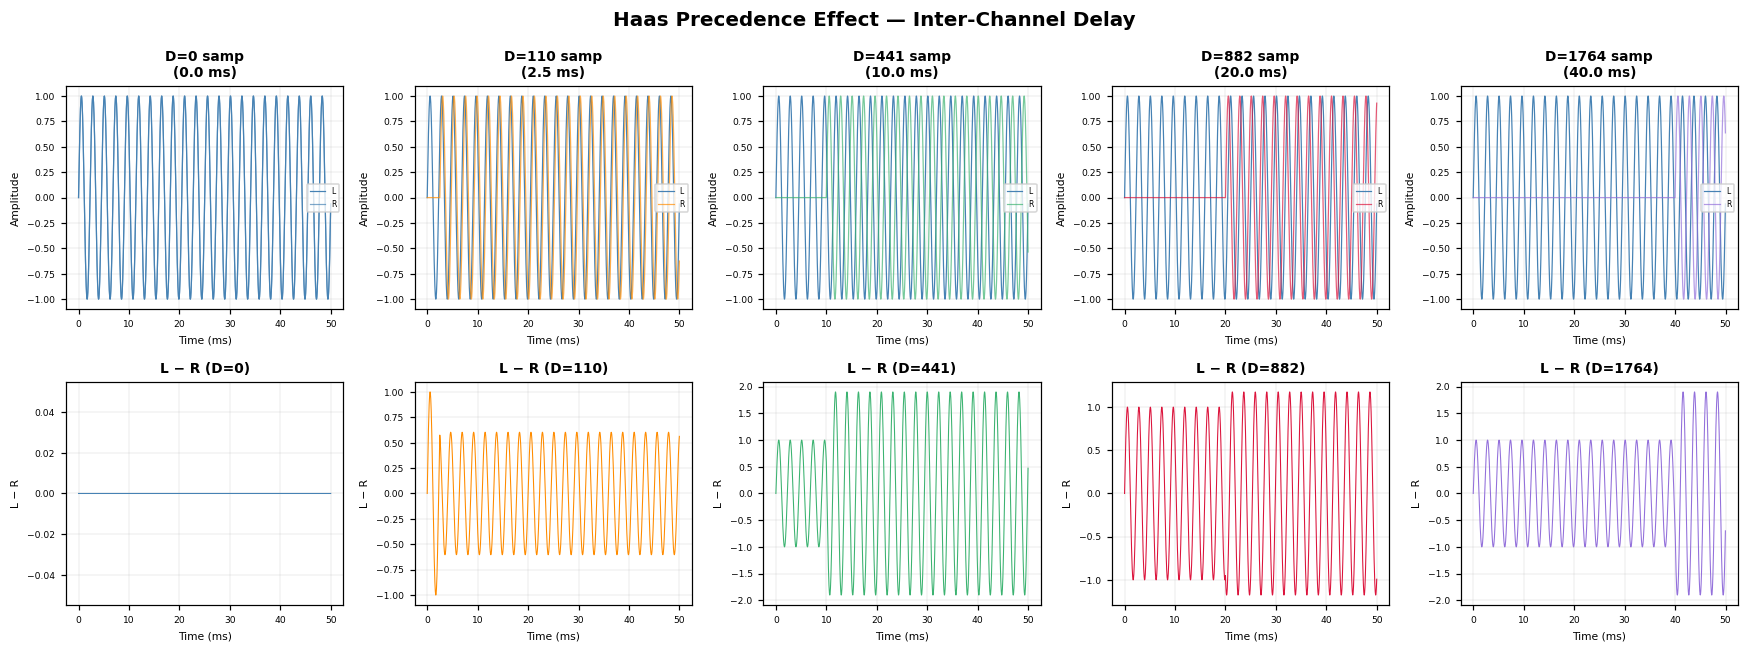

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 0.05

_, mono = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(mono)) / FS * 1000

DELAYS = [0, 110, 441, 882, 1764]  # 0, 2.5, 10, 20, 40 ms
COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson", "mediumpurple"]

fig, axes = plt.subplots(2, len(DELAYS), figsize=(16, 6))

for col, (d, color) in enumerate(zip(DELAYS, COLORS)):
    L, R = haas(mono, delay_samples=d)
    ms = d / FS * 1000
    axes[0, col].plot(t_ms, L, linewidth=0.8, color="steelblue", label="L")
    axes[0, col].plot(t_ms, R, linewidth=0.8, color=color, alpha=0.7, label="R")
    axes[0, col].set_title(f"D={d} samp\n({ms:.1f} ms)", fontsize=9, fontweight="bold")
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)
    axes[0, col].tick_params(labelsize=6)
    axes[0, col].legend(fontsize=5)
    axes[0, col].grid(True, linewidth=0.3, alpha=0.5)

    # L-R difference (reveals the delay)
    diff = L - R
    axes[1, col].plot(t_ms, diff, linewidth=0.7, color=color)
    axes[1, col].set_title(f"L − R (D={d})", fontsize=9, fontweight="bold")
    axes[1, col].set_xlabel("Time (ms)", fontsize=7)
    axes[1, col].set_ylabel("L − R", fontsize=7)
    axes[1, col].tick_params(labelsize=6)
    axes[1, col].grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Haas Precedence Effect — Inter-Channel Delay", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()